## Transition Zone

In [1]:
from smode_import import *

SMODE_DATA_folder = '/Users/elise/data/SMODE-data/'
dr_files = sorted(glob(SMODE_DATA_folder+'drifters/2023/'+'SMODE_IOP2_surface_drifter_0*.nc'))

ds = xr.open_dataset('dopplerscatt_gridded.nc')
uw = xr.open_dataset(SMODE_DATA_folder+'TSG/'+'IOP2_underway.nc')

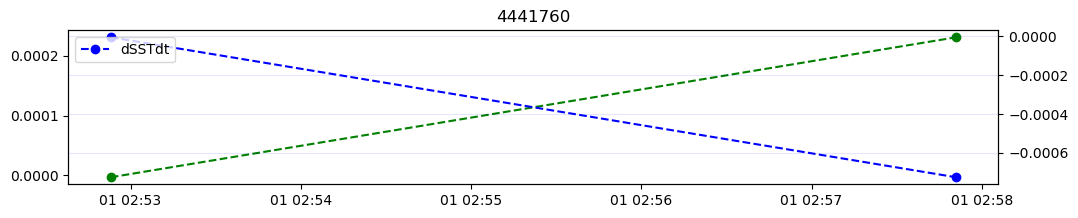

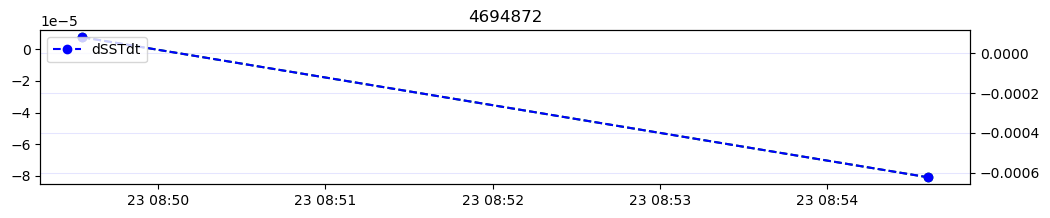

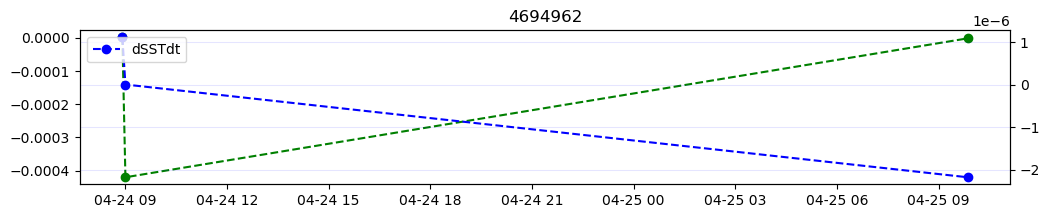

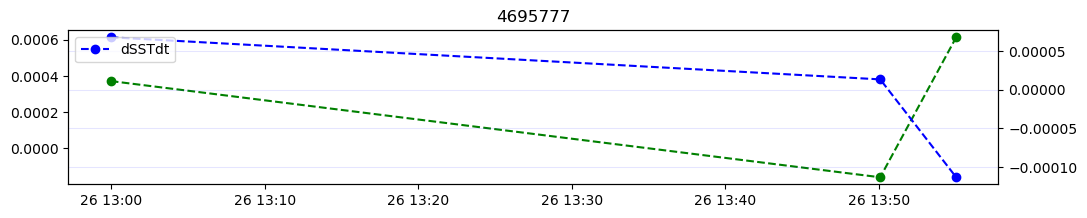

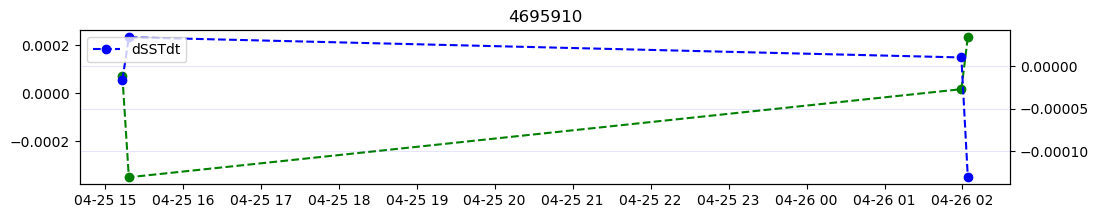

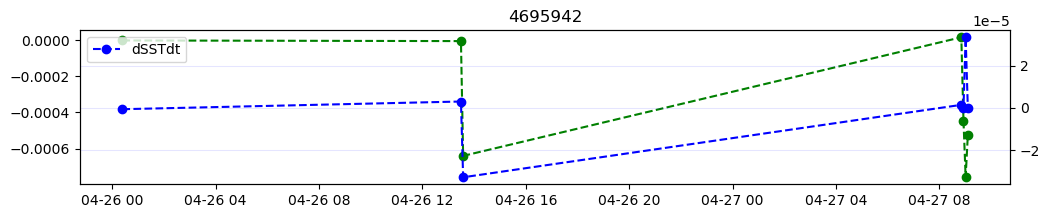

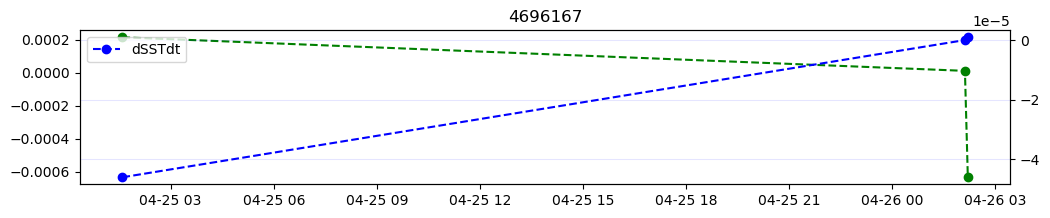

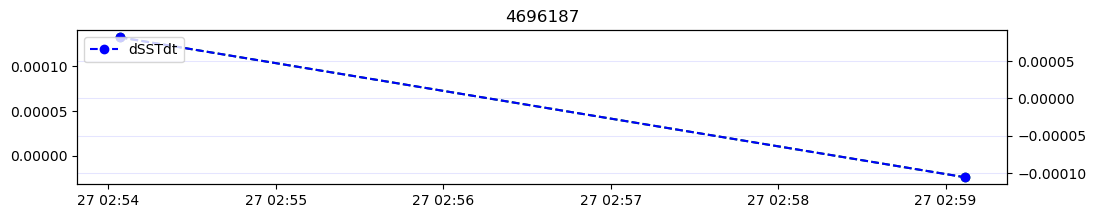

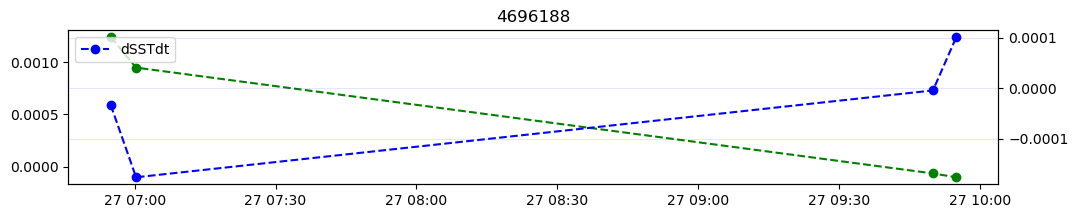

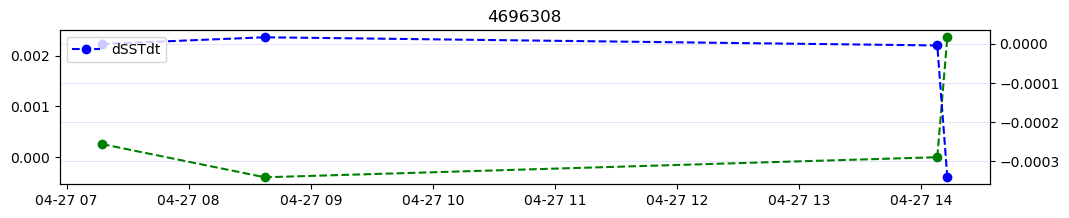

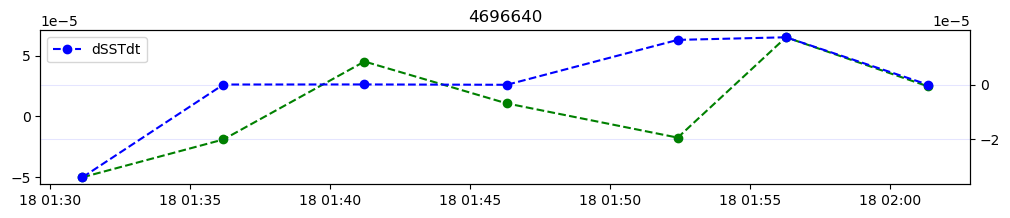

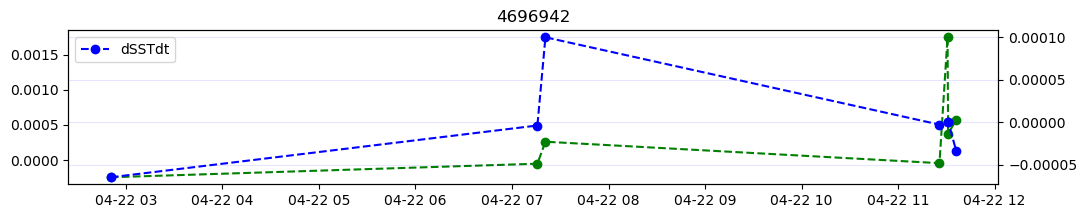

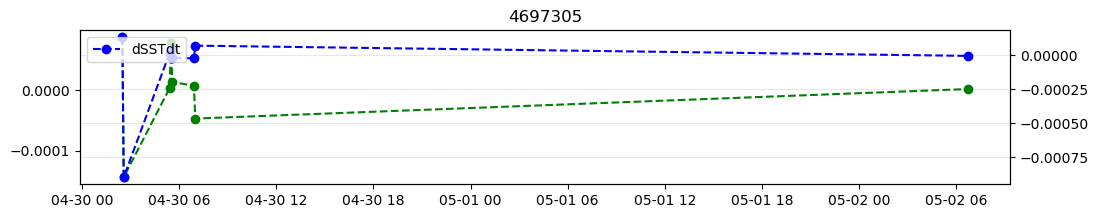

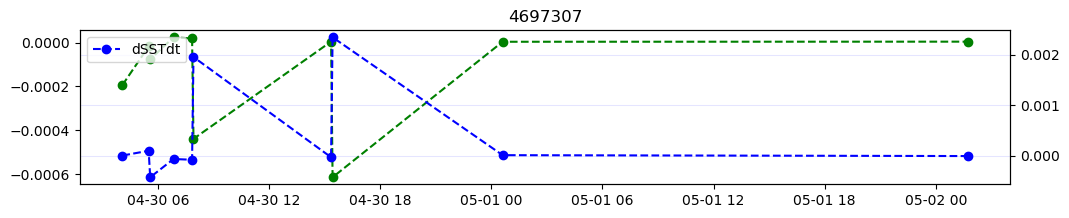

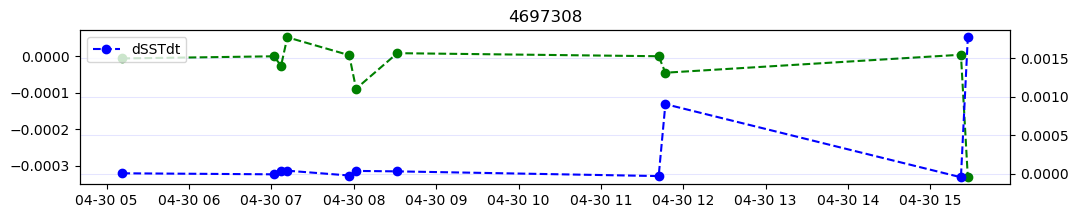

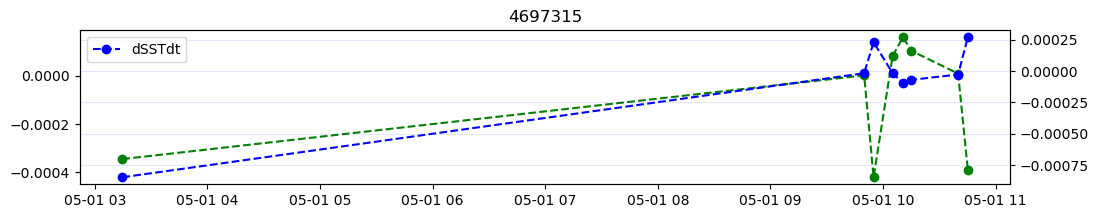

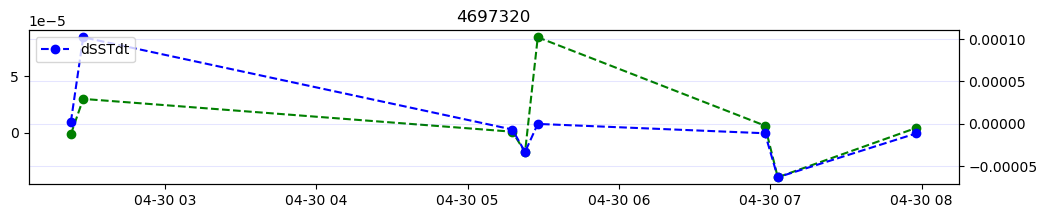

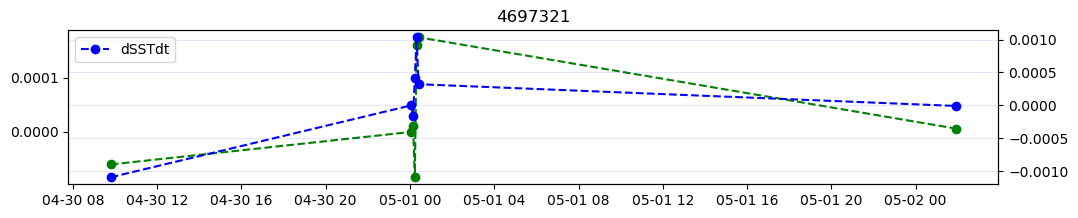

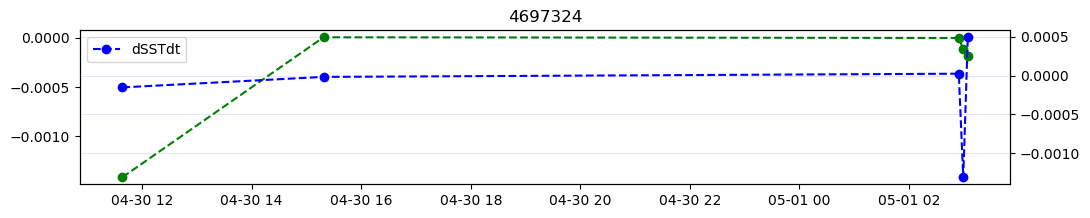

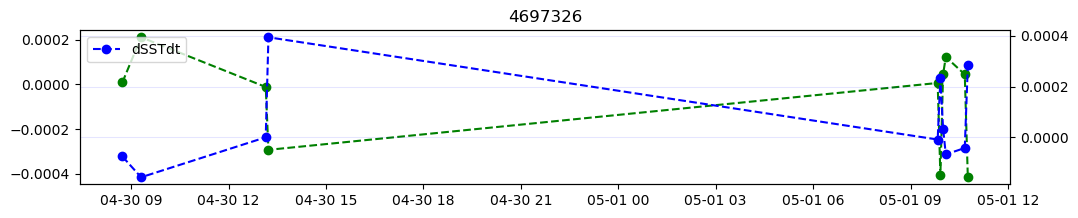

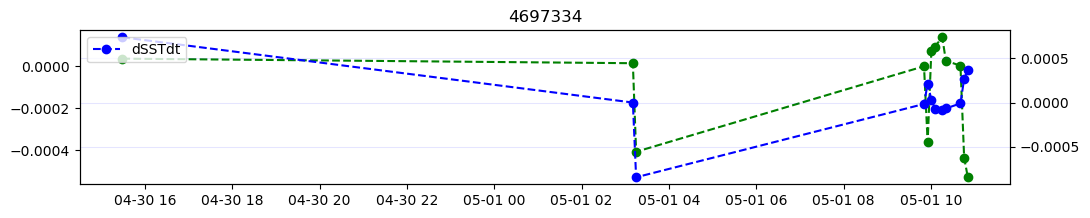

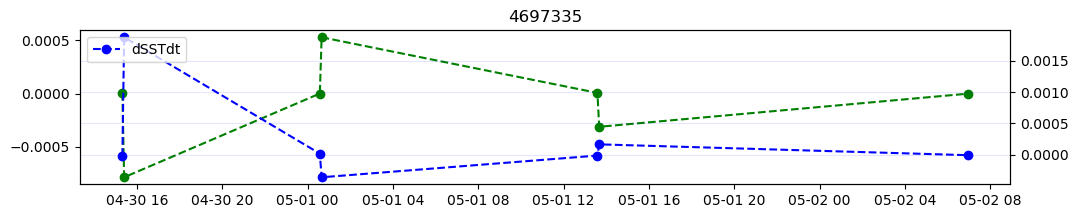

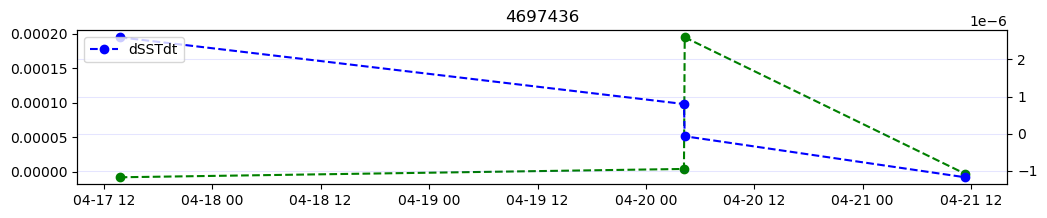

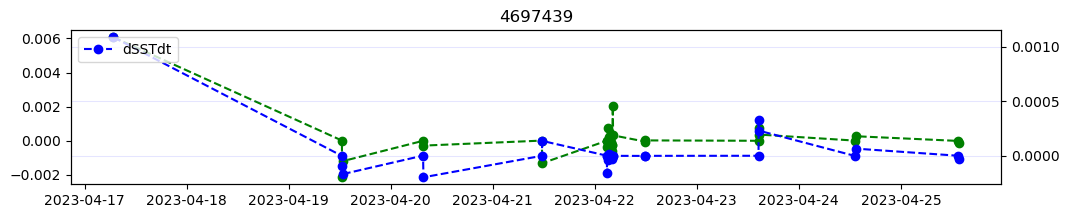

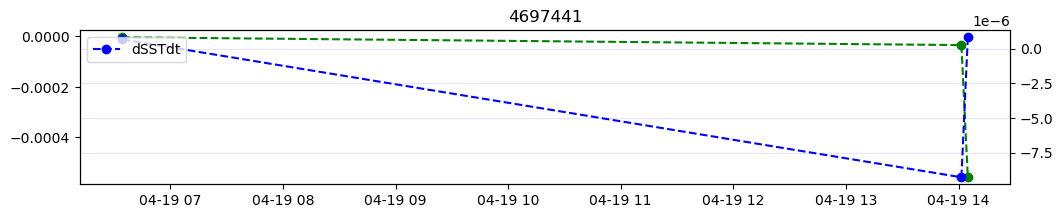

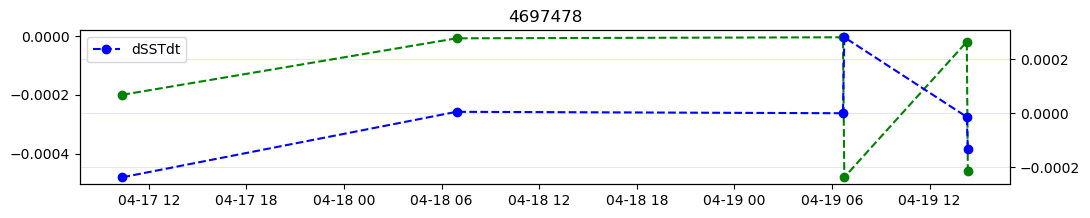

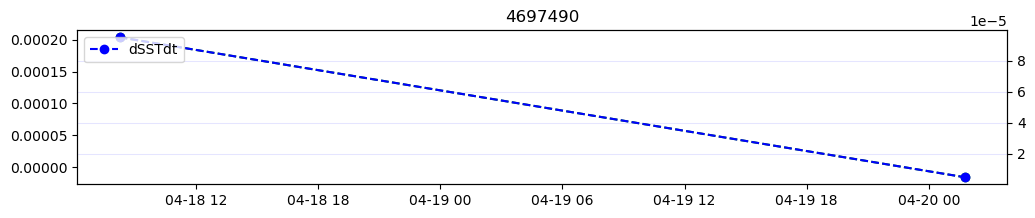

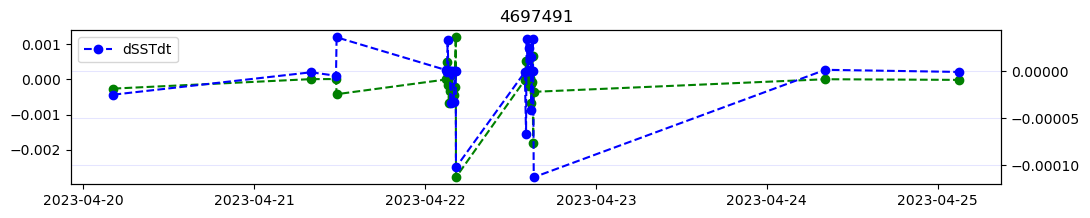

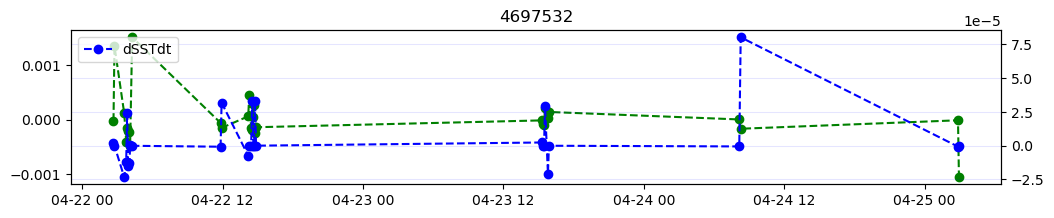

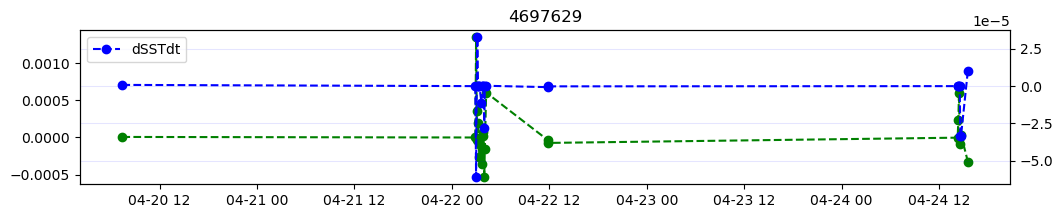

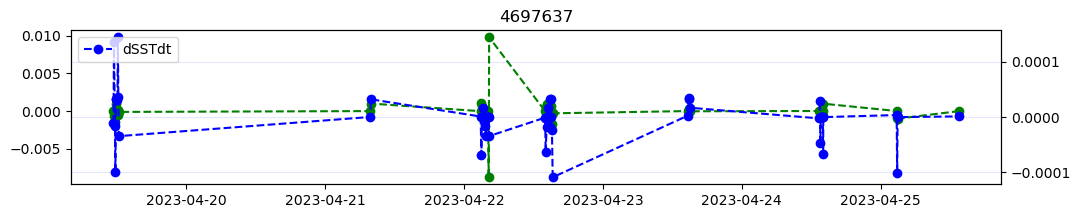

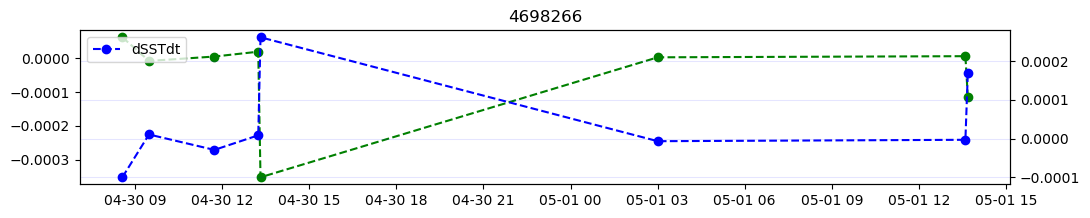

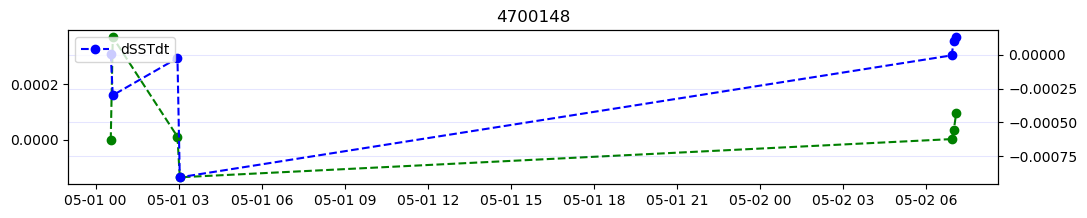

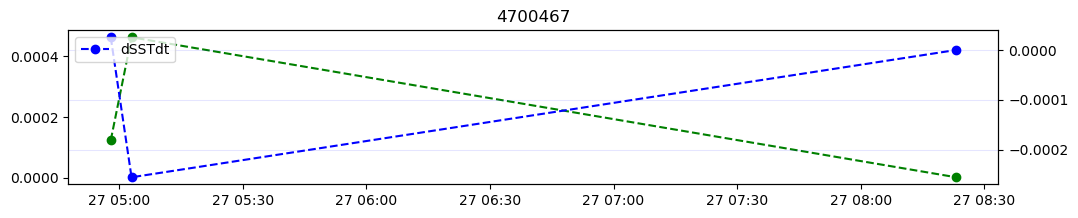

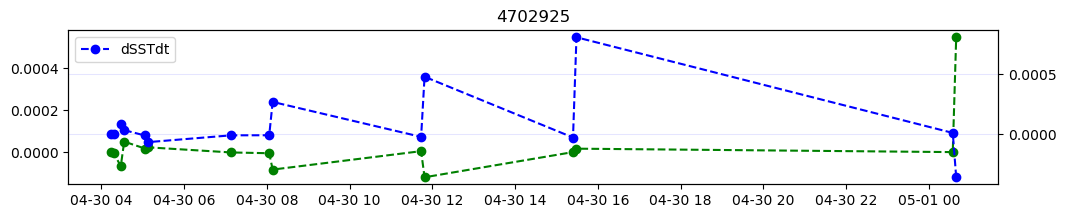

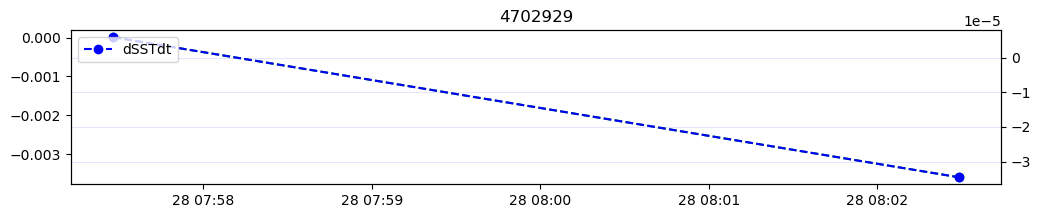

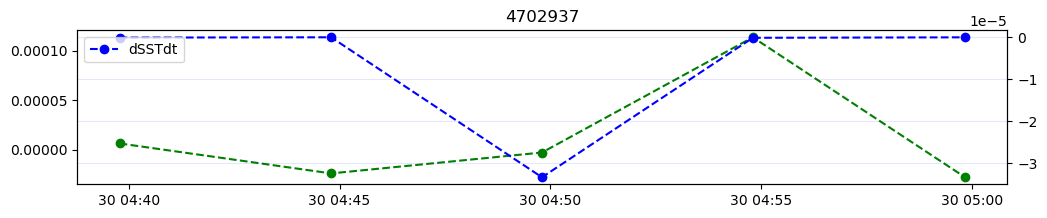

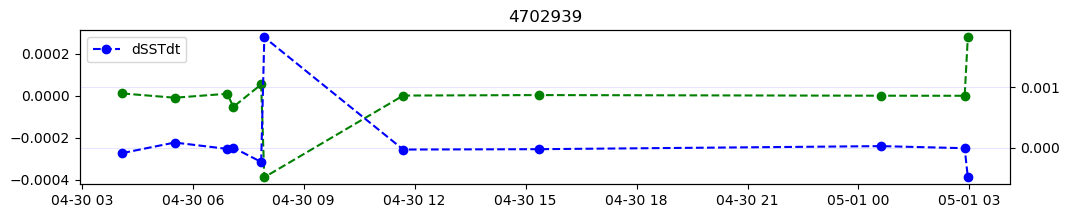

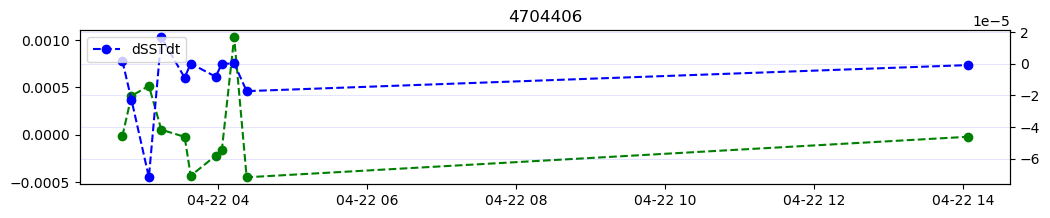

In [63]:
# time series

dChldt = []
dSSTdt = []
lons   = []
lats   = []
r      = []
p      = []
mean_lon=[]

for file in dr_files:
    dr = xr.open_dataset(file)
    dr = dr.isel(time=dr.position_QCflag==1) # keep good data only
    dr = interp_ship_on_drifter(uw, dr)
    
    if dr.dims['time']>2:
        #dr = dr.resample(time='2H').mean()
        
        fig,ax=plt.subplots(1,1,figsize=(12,2))
        ax.plot(dr.time, dr.dChldt, 'o--g', label='dChldt',zorder=101)
        ax2=ax.twinx()
        ax2.plot(dr.time, dr.dSSTdt, 'o--b', label='dSSTdt')
        
        plt.legend(loc='upper left')
        plt.title(dr.name)
        plt.grid(color='b',alpha=0.1)
        #plt.xlim(pd.to_datetime('2023-04-19'),pd.to_datetime('2023-04-25'))
        plt.show();
        
        # compute correlation
        idx = ~np.isnan(dr.dChldt.values)
        r_ = scipy.stats.pearsonr(dr.dChldt.values[idx], dr.dSSTdt.values[idx])[0]
        p_ = scipy.stats.pearsonr(dr.dChldt.values[idx], dr.dSSTdt.values[idx])[1]
        
        # save values
        dChldt.append(dr.dChldt.values)
        dSSTdt.append(dr.dSSTdt.values)
        lons.append(dr.lon.values)
        lats.append(dr.lat.values)
        r.append(r_)
        p.append(p_)
        mean_lon.append(dr.lon.mean())

dChldt = np.array(np.concatenate(dChldt))
dSSTdt = np.array(np.concatenate(dSSTdt))
lons   = np.array(np.concatenate(lons))
lats   = np.array(np.concatenate(lats))
r      = np.array(r)
p      = np.array(p)
mean_lon=np.array(mean_lon)

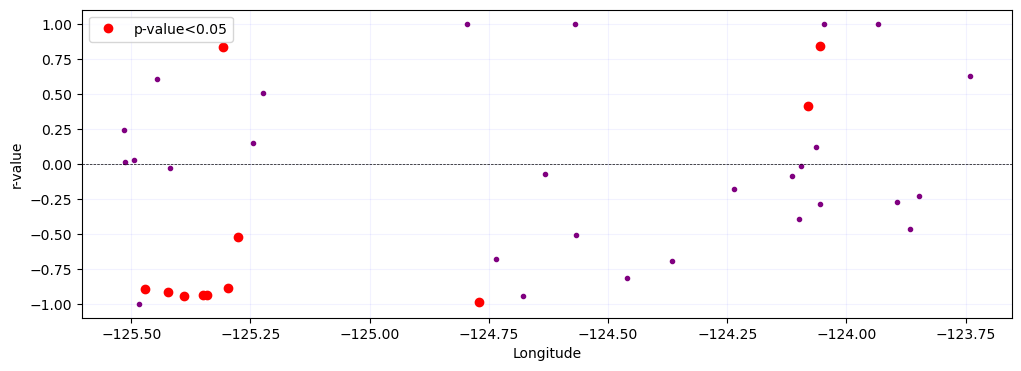

In [65]:
plt.figure(figsize=(12,4))
plt.plot(mean_lon,r,'.',color='purple')

plt.plot(mean_lon[p<=0.05],r[p<=0.05],'or',label='p-value<0.05')

plt.axhline(0,linestyle='--',linewidth=0.5,color='k')

plt.grid(color='blue',alpha=0.05)
plt.ylabel('r-value')
plt.xlabel('Longitude')
plt.legend()
plt.show();

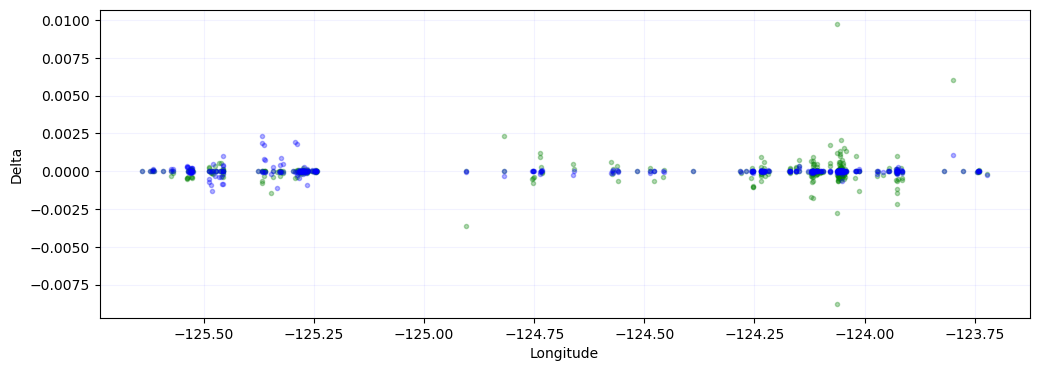

In [51]:
plt.figure(figsize=(12,4))
plt.plot(lons, dChldt,'.g',alpha=0.3)
plt.plot(lons, dSSTdt,'.b',alpha=0.3)
#plt.ylim(-1e-3,1e-3)
plt.grid(color='blue',alpha=0.05)
plt.ylabel('Delta')
plt.xlabel('Longitude');